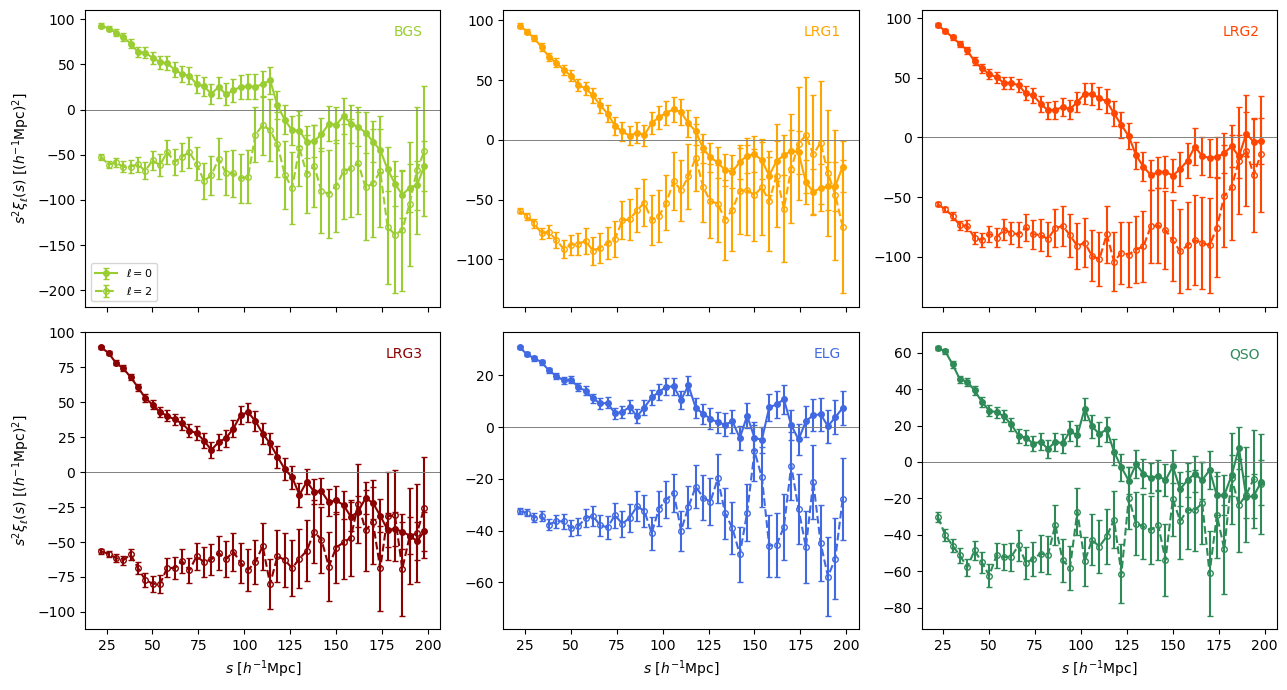

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from pycorr import TwoPointCorrelationFunction

DATA_DIR = Path('/spiffball/cosweeney/DESI/DR1/CorrFuncs/gccomb/gccomb')
COV_DIR = Path('/spiffball/cosweeney/DESI/DR1/covariances')

SMIN, SMAX, DS = 20., 200., 4.
NBINS = int(round((SMAX - SMIN) / DS))  # 45
ELLS = (0, 2, 4)

# label -> (tracer string as it appears in filenames, zmin, zmax, nran)
TRACERS = {
    'BGS':  ('BGS_BRIGHT-21.5', 0.1, 0.4, 1),
    'LRG1': ('LRG',             0.4, 0.6, 8),
    'LRG2': ('LRG',             0.6, 0.8, 8),
    'LRG3': ('LRG',             0.8, 1.1, 8),
    'ELG':  ('ELG_LOPnotqso',   1.1, 1.6, 10),
    'QSO':  ('QSO',             0.8, 2.1, 4),
}

COLORS = {
    'BGS': 'yellowgreen', 'LRG1': 'orange', 'LRG2': 'orangered',
    'LRG3': 'darkred', 'ELG': 'royalblue', 'QSO': 'seagreen',
}


def poles_path(tracer, zmin, zmax, nran):
    return DATA_DIR / (f'allcounts_{tracer}_GCcomb_z{zmin}-{zmax}_default_FKP_lin_'
                        f'nran{nran}_njack0_split20_thetacut0.05.npy')


def cov_path(tracer, zmin, zmax):
    return COV_DIR / (f'xi024_{tracer}_GCcomb_{zmin}_{zmax}_default_FKP_lin4_'
                       f's20-200_cov_RascalC_rescaled.txt')


def load_multipoles(tracer, zmin, zmax, nran):
    """Load pair counts with pycorr, cut to [SMIN, SMAX], and rebin to DS spacing
    so the resulting s-grid matches the covariance's 45 bins.

    NOTE: `.select()` for restricting the separation range and `[::factor]` for
    rebinning reflect the pycorr API as of the DESI Y1 analysis scripts I'm aware
    of. Please double check both calls against the pycorr version installed on
    spiffball/spiffball -- if either has been renamed/changed, only these two
    lines need to change.
    """
    result = TwoPointCorrelationFunction.load(poles_path(tracer, zmin, zmax, nran))
    result = result.select((SMIN, SMAX))
    binwidth = np.diff(result.edges[0])[0]
    rebin_factor = int(round(DS / binwidth))
    if rebin_factor > 1:
        result = result[::rebin_factor]
    s, xiell = result(ells=ELLS, return_sep=True)
    return np.asarray(s), np.asarray(xiell)


def load_errors(tracer, zmin, zmax):
    cov = np.loadtxt(cov_path(tracer, zmin, zmax))
    diag = np.diag(cov)
    n_ells = len(ELLS)
    assert diag.size == n_ells * NBINS, (
        f'cov diag has {diag.size} entries, expected {n_ells * NBINS} '
        f'({n_ells} ells x {NBINS} s-bins) -- check ELLS/NBINS against the cov file'
    )
    return np.sqrt(diag).reshape(n_ells, NBINS)


fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)

for ax, (label, (tracer, zmin, zmax, nran)) in zip(axes.flat, TRACERS.items()):
    s, xiell = load_multipoles(tracer, zmin, zmax, nran)
    err = load_errors(tracer, zmin, zmax)
    color = COLORS[label]

    for i, (ell, marker, ls) in enumerate(zip(ELLS, ['o', 'o'], ['-', '--'])):
        facecolor = color if ell == 0 else 'none'
        ax.errorbar(s, s**2 * xiell[i], yerr=s**2 * err[i],
                    fmt=marker, ls=ls, color=color, mfc=facecolor,
                    ms=4, capsize=2, label=rf'$\ell={ell}$')

    ax.axhline(0, color='gray', lw=0.7)
    ax.text(0.95, 0.95, label, transform=ax.transAxes, ha='right', va='top', color=color)
    if ax in axes[-1, :]:
        ax.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$')
    if ax in axes[:, 0]:
        ax.set_ylabel(r'$s^2\xi_\ell(s)\ [(h^{-1}\mathrm{Mpc})^2]$')

axes.flat[0].legend(loc='lower left', fontsize=8)
fig.tight_layout()
plt.show()

In [8]:
import numpy as np
from pathlib import Path
from scipy.special import eval_legendre
from pycorr import TwoPointCorrelationFunction

# Run this in your pycorr environment. It has no tensorflow dependency at all --
# output is a plain .npz that the tensorflow-side script (validate_window_bias_step2.py)
# reads independently.

DATA_DIR = Path('/spiffball/cosweeney/DESI/DR1/CorrFuncs/gccomb/gccomb')
S_MODEL = np.arange(16.0, 169.0 + 4.0, 1.0)  # must match the emulator's grid in step 2


def poles_path(tracer, zmin, zmax, nran, thetacut):
    suffix = '_thetacut0.05' if thetacut else ''
    return DATA_DIR / (f'allcounts_{tracer}_GCcomb_z{zmin}-{zmax}_default_FKP_lin_'
                        f'nran{nran}_njack0_split20{suffix}.npy')


def theta_cut_window(rr_counter, ells_obs=(0, 2, 4), ells_theory=(0, 2, 4)):
    """W^cut_{ell,ell'}(s) on the counter's native fine s-grid, per Pinon et al. Eq 3.5."""
    s_edges, mu_edges = rr_counter.edges
    mu_centers = 0.5 * (mu_edges[:-1] + mu_edges[1:])
    dmu = np.diff(mu_edges)
    n_s = rr_counter.wcounts.shape[0]
    s_centers = 0.5 * (s_edges[:-1] + s_edges[1:])

    W = np.zeros((len(ells_obs), len(ells_theory), n_s))
    for i_s in range(n_s):
        mask = rr_counter.wcounts[i_s] != 0.
        total_width = dmu[mask].sum()
        if total_width == 0.:
            continue
        Lo_all = {lo: eval_legendre(lo, mu_centers[mask]) for lo in ells_obs}
        for i_lo, lo in enumerate(ells_obs):
            for i_lt, lt in enumerate(ells_theory):
                Lt = eval_legendre(lt, mu_centers[mask])
                W[i_lo, i_lt, i_s] = (2 * lo + 1) * np.sum(Lo_all[lo] * Lt * dmu[mask]) / total_width
    return W, s_centers


def window_at(W, s_fine, s_query):
    n_lo, n_lt, _ = W.shape
    out = np.empty((n_lo, n_lt, len(s_query)))
    for i in range(n_lo):
        for j in range(n_lt):
            out[i, j] = np.interp(s_query, s_fine, W[i, j])
    return out


def extract_window(tracer_str, zmin, zmax, nran, out_path):
    result_cut = TwoPointCorrelationFunction.load(poles_path(tracer_str, zmin, zmax, nran, thetacut=True))
    W_fine, s_fine = theta_cut_window(result_cut.S1S2)
    W_on_smodel = window_at(W_fine, s_fine, S_MODEL)  # (3, 3, len(S_MODEL))
    np.savez(out_path, W=W_on_smodel, s_model=S_MODEL, ells=np.array([0, 2, 4]))
    print(f'Saved window to {out_path}, shape {W_on_smodel.shape}')


TRACER_ZBINS = {
    'BGS_BRIGHT-21.5': (1,  [(0.1, 0.4)]),
    'LRG':           (8,  [(0.4, 0.6), (0.6, 0.8), (0.8, 1.1)]),
    'ELG_LOPnotqso': (10, [(1.1, 1.6)]),
    'QSO':           (4,  [(0.8, 2.1)]),
}


def out_name(tracer, zmin, zmax):
    return f'window_{tracer}_z{zmin}-{zmax}.npz'


if __name__ == '__main__':
    for tracer, (nran, zbins) in TRACER_ZBINS.items():
        for zmin, zmax in zbins:
            extract_window(tracer, zmin, zmax, nran, out_path=out_name(tracer, zmin, zmax))

Saved window to window_BGS_BRIGHT-21.5_z0.1-0.4.npz, shape (3, 3, 157)
Saved window to window_LRG_z0.4-0.6.npz, shape (3, 3, 157)
Saved window to window_LRG_z0.6-0.8.npz, shape (3, 3, 157)
Saved window to window_LRG_z0.8-1.1.npz, shape (3, 3, 157)
Saved window to window_ELG_LOPnotqso_z1.1-1.6.npz, shape (3, 3, 157)
Saved window to window_QSO_z0.8-2.1.npz, shape (3, 3, 157)


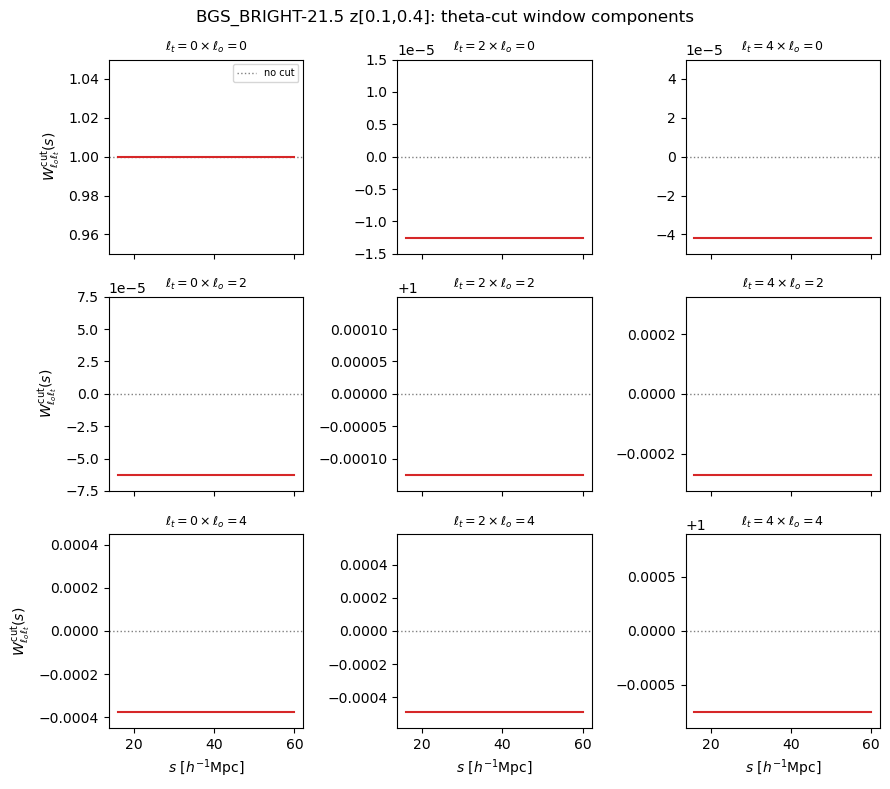

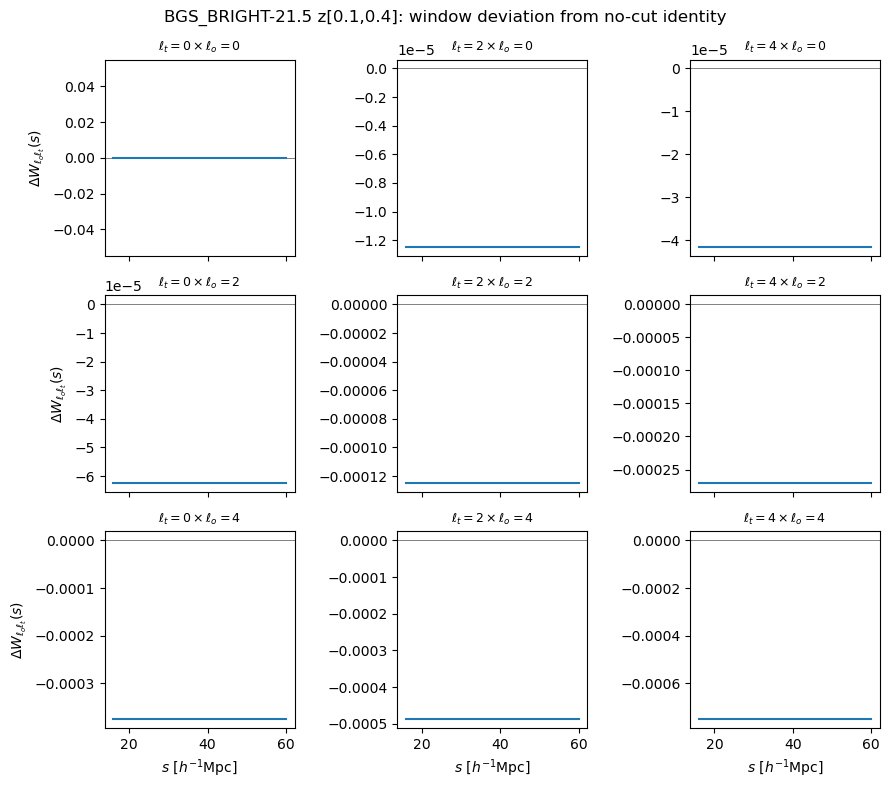

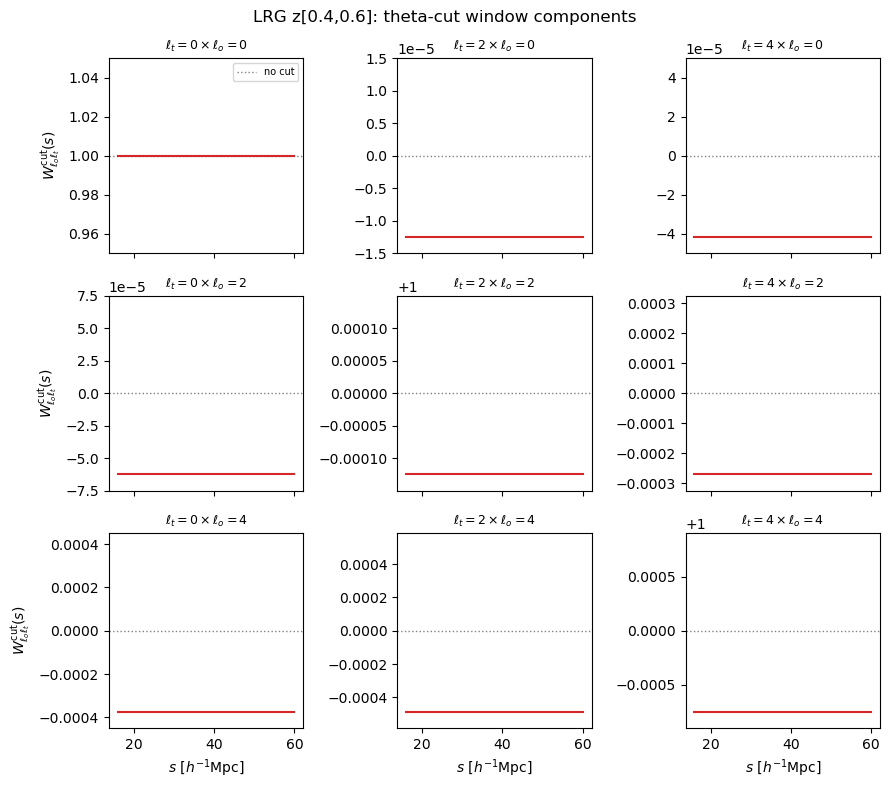

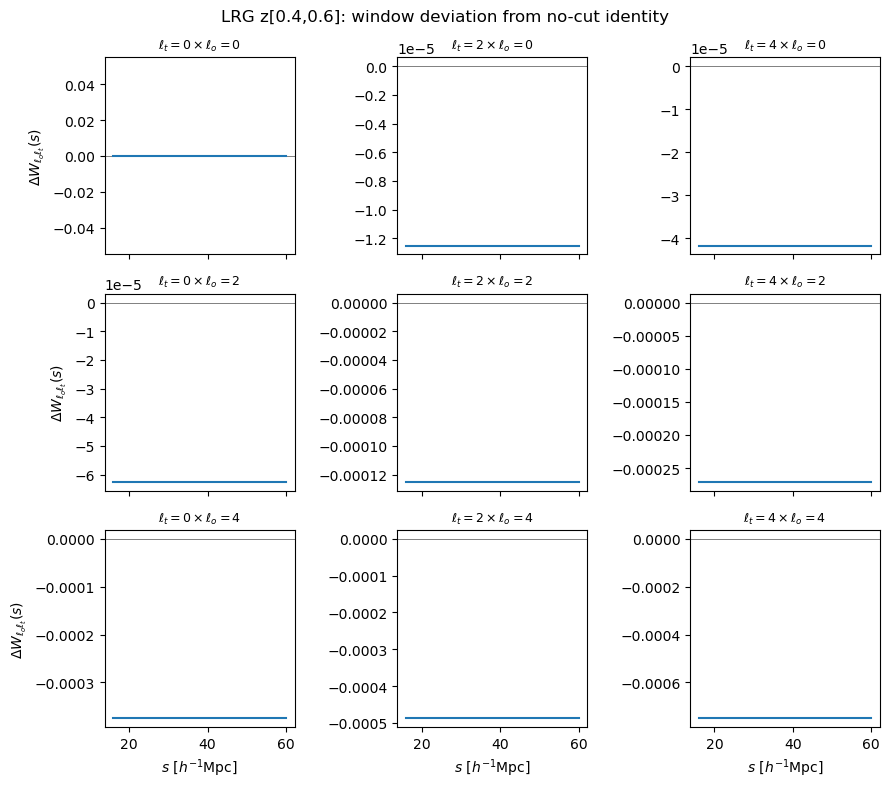

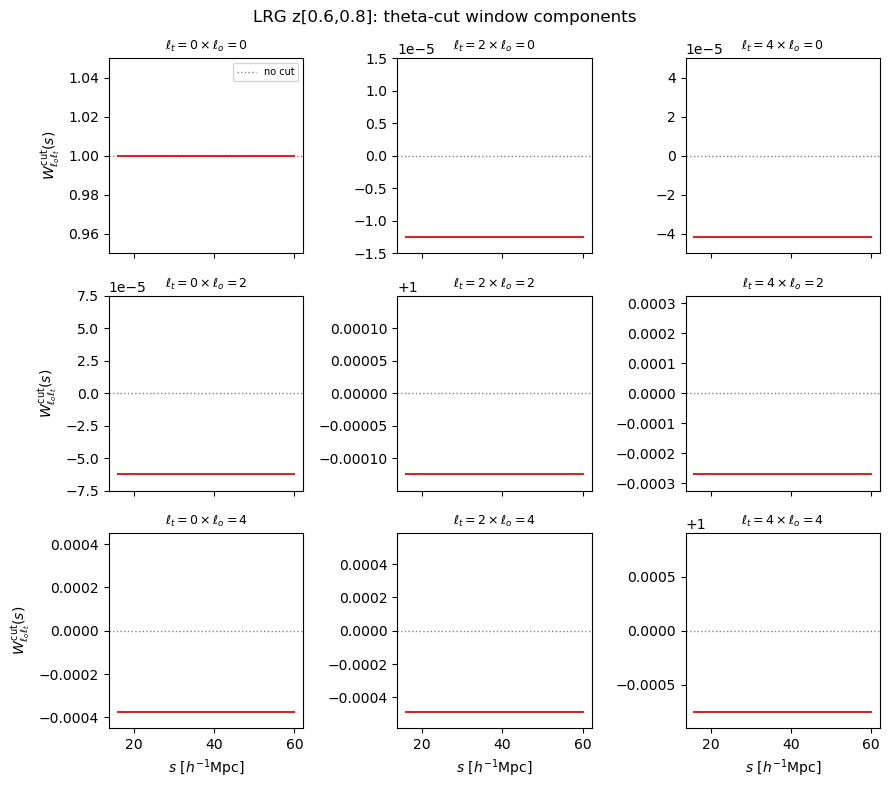

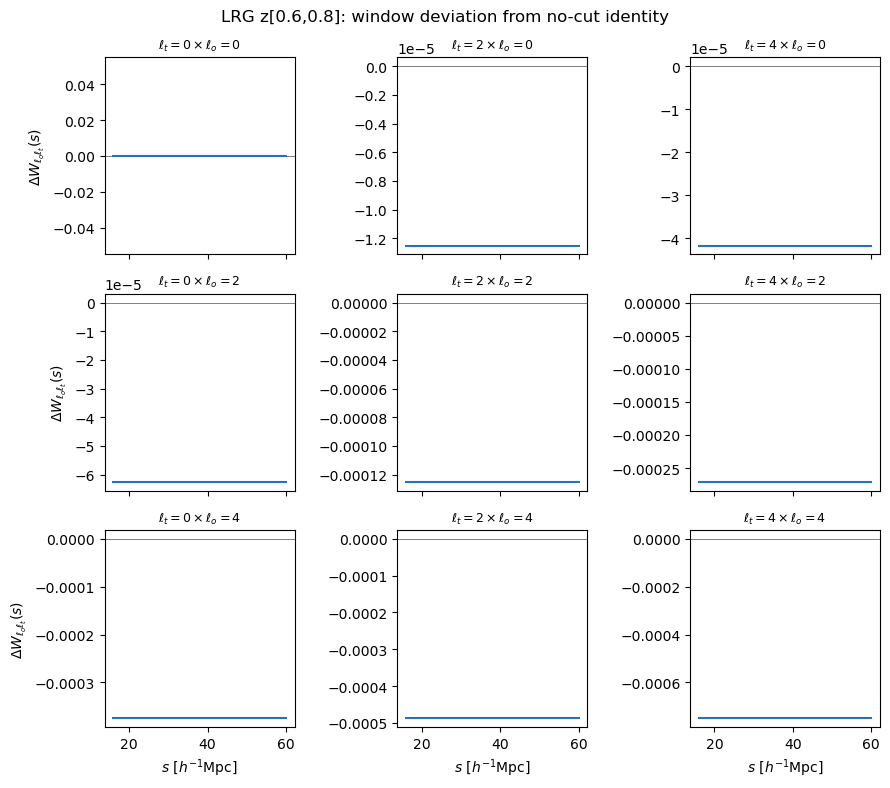

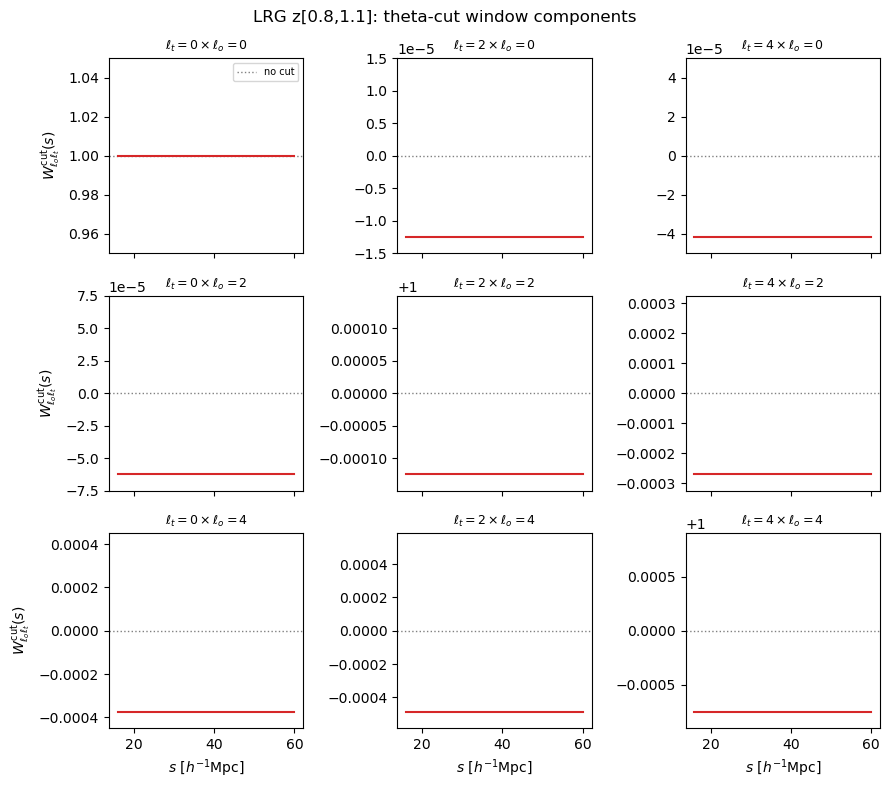

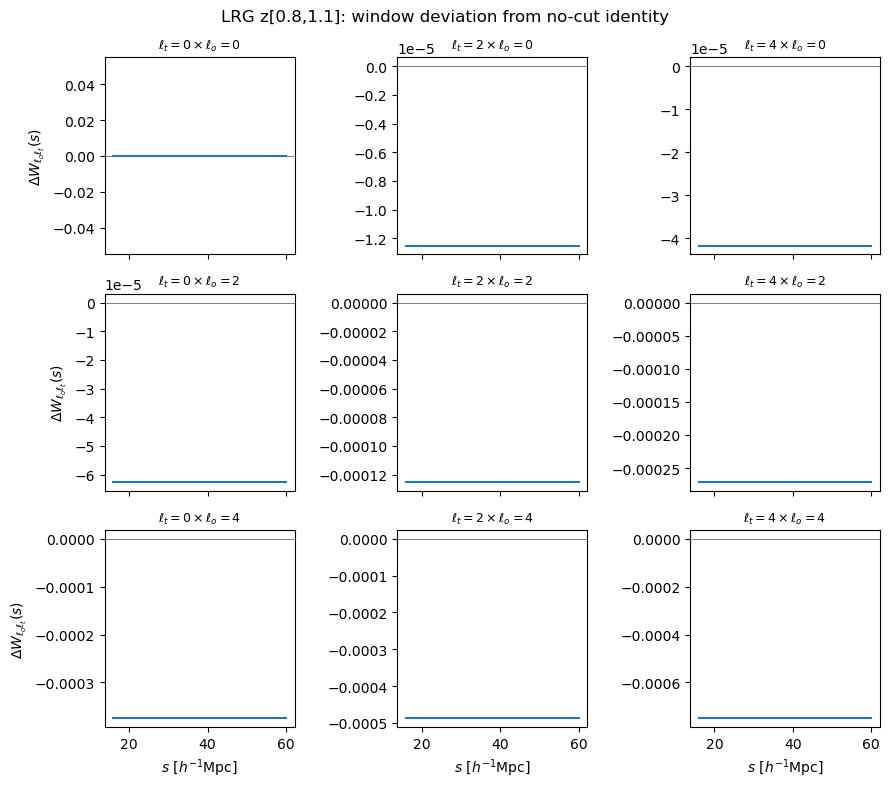

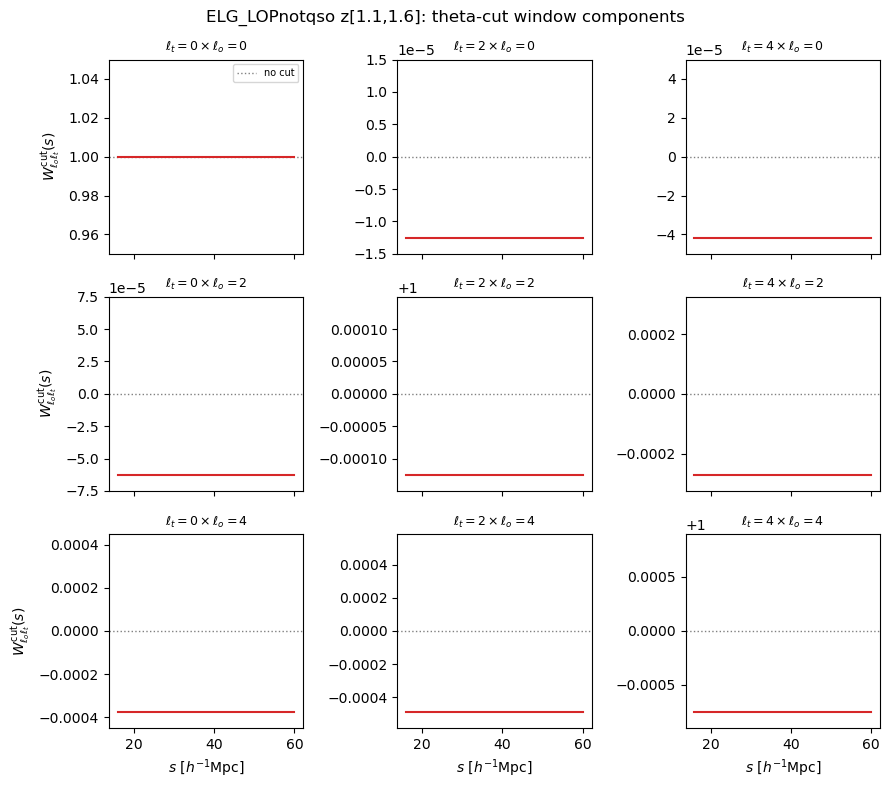

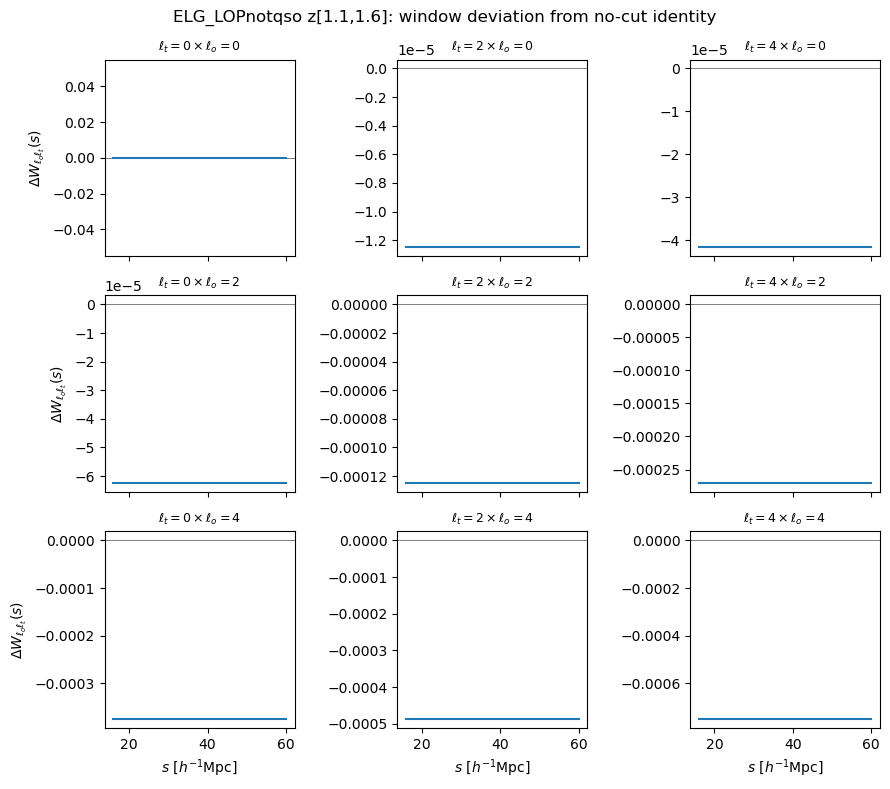

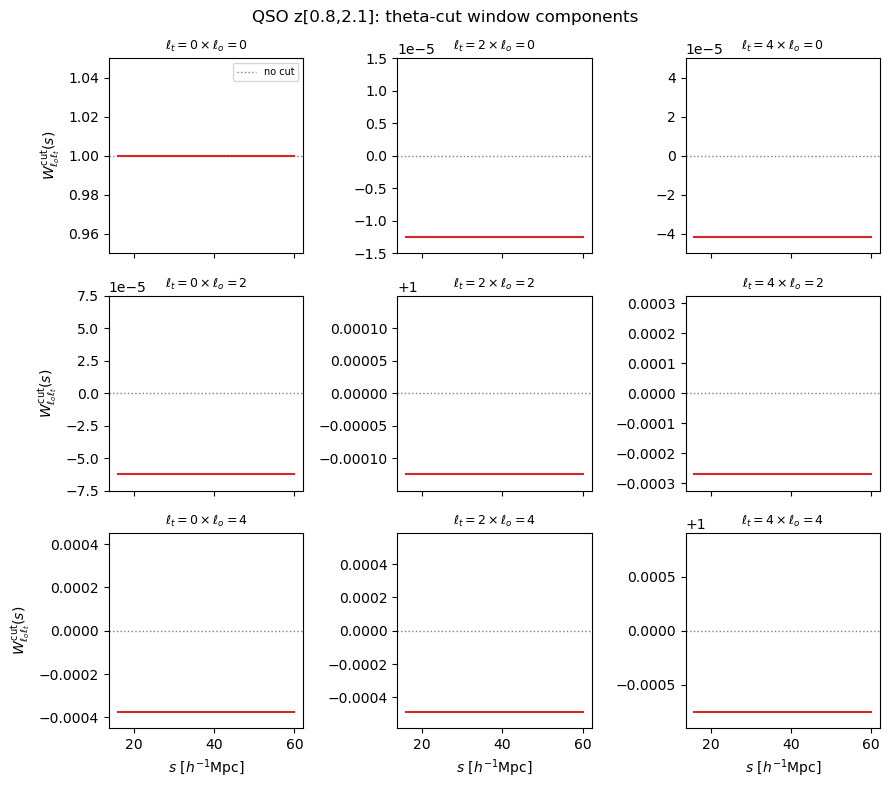

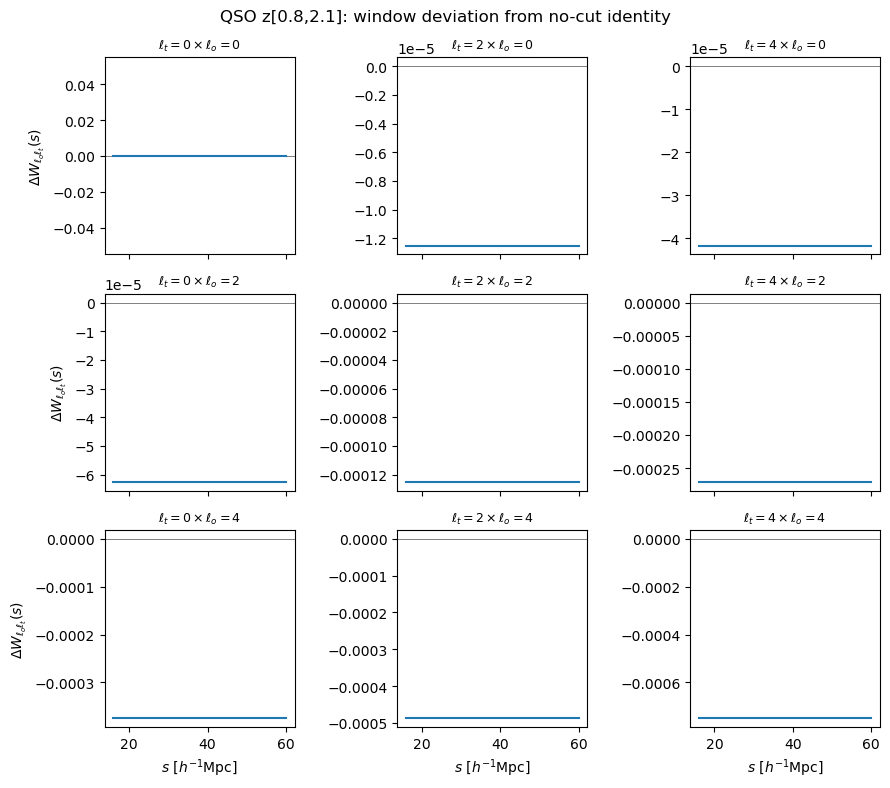

In [9]:
import numpy as np
import matplotlib.pyplot as plt

ELLS = (0, 2, 4)

TRACER_ZBINS = [
    ('BGS_BRIGHT-21.5', 0.1, 0.4),
    ('LRG', 0.4, 0.6),
    ('LRG', 0.6, 0.8),
    ('LRG', 0.8, 1.1),
    ('ELG_LOPnotqso', 1.1, 1.6),
    ('QSO', 0.8, 2.1),
]


def plot_window(tracer, zmin, zmax, npz_path=None, smax_plot=60.):
    npz_path = npz_path or f'window_{tracer}_z{zmin}-{zmax}.npz'
    npz = np.load(npz_path)
    W, s_model = npz['W'], npz['s_model']  # W shape (n_lo, n_lt, n_s)
    mask = s_model <= smax_plot

    # --- Figure 1: W_ll'(s) itself, y-axis centered on the "no cut" reference ---
    # For a full (uncut) mu range, Legendre orthogonality makes this exactly the
    # identity: W_ll'(s) = 1 for l=l', 0 otherwise. Centering each panel's ylim on
    # that reference (symmetric +/- the largest deviation seen) makes deviations
    # visually comparable across panels rather than dominated by axis auto-scaling.
    fig, axes = plt.subplots(3, 3, figsize=(9, 8), sharex=True)
    for i_lo, lo in enumerate(ELLS):
        for i_lt, lt in enumerate(ELLS):
            ax = axes[i_lo, i_lt]
            ref = 1. if lo == lt else 0.
            curve = W[i_lo, i_lt, mask]
            ax.axhline(ref, color='gray', ls=':', lw=1, label='no cut' if (i_lo, i_lt) == (0, 0) else None)
            ax.plot(s_model[mask], curve, color='C3', lw=1.5)
            max_dev = np.max(np.abs(curve - ref))
            pad = max_dev * 1.2 if max_dev > 0 else 0.05
            ax.set_ylim(ref - pad, ref + pad)
            ax.set_title(rf'$\ell_t={lt} \times \ell_o={lo}$', fontsize=9)
            if i_lo == 2:
                ax.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$')
            if i_lt == 0:
                ax.set_ylabel(r'$W^{\rm cut}_{\ell_o \ell_t}(s)$')
    axes[0, 0].legend(fontsize=7, loc='best')
    fig.suptitle(f'{tracer} z[{zmin},{zmax}]: theta-cut window components')
    fig.tight_layout()
    plt.show()

    # --- Figure 2: deviation from the no-cut identity, DeltaW = W - I ---
    # Direct analog of Pinon et al. Fig 6 ("contribution of small-theta pairs to
    # the window"), just shown vs s instead of as a (k,k') heatmap.
    fig2, axes2 = plt.subplots(3, 3, figsize=(9, 8), sharex=True)
    for i_lo, lo in enumerate(ELLS):
        for i_lt, lt in enumerate(ELLS):
            ax = axes2[i_lo, i_lt]
            ref = 1. if lo == lt else 0.
            delta = W[i_lo, i_lt, mask] - ref
            ax.axhline(0, color='gray', lw=0.7)
            ax.plot(s_model[mask], delta, color='C0', lw=1.5)
            ax.set_title(rf'$\ell_t={lt} \times \ell_o={lo}$', fontsize=9)
            if i_lo == 2:
                ax.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$')
            if i_lt == 0:
                ax.set_ylabel(r'$\Delta W_{\ell_o \ell_t}(s)$')
    fig2.suptitle(f'{tracer} z[{zmin},{zmax}]: window deviation from no-cut identity')
    fig2.tight_layout()
    plt.show()


if __name__ == '__main__':
    for tracer, zmin, zmax in TRACER_ZBINS:
        plot_window(tracer, zmin, zmax, smax_plot=60.)

Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|: 9.992007221626409e-16

LRG z[0.4,0.6] -- window impact on theory, s in [16.0, 30.0]:
  ell=0: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=2: max |diff|/sigma = 0.002, at s = 16 Mpc/h


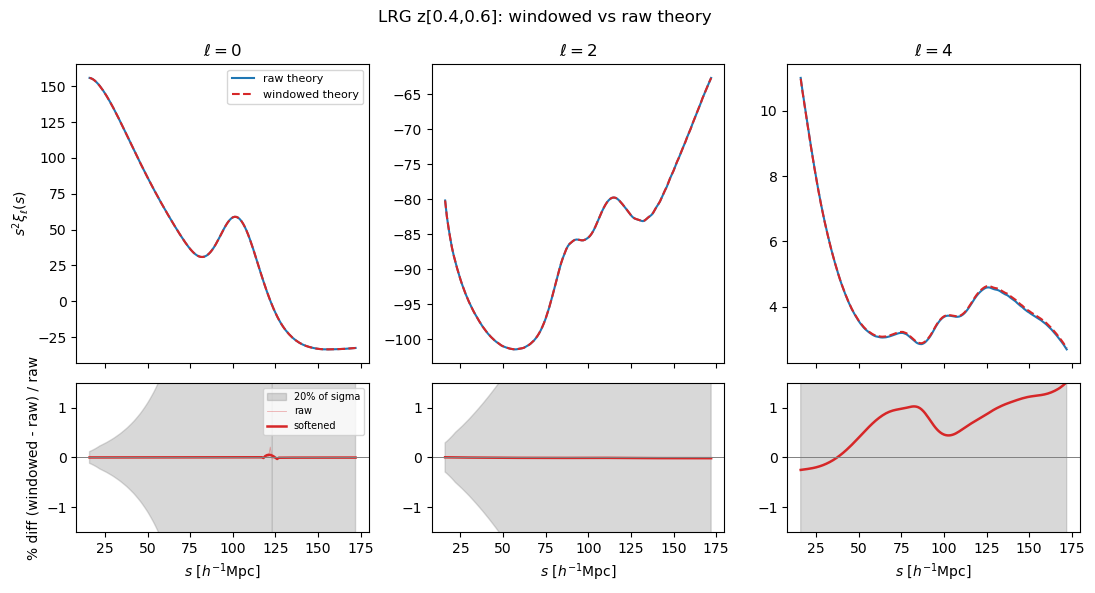

Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|: 6.661338147750939e-16

LRG z[0.6,0.8] -- window impact on theory, s in [16.0, 30.0]:
  ell=0: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=2: max |diff|/sigma = 0.002, at s = 16 Mpc/h


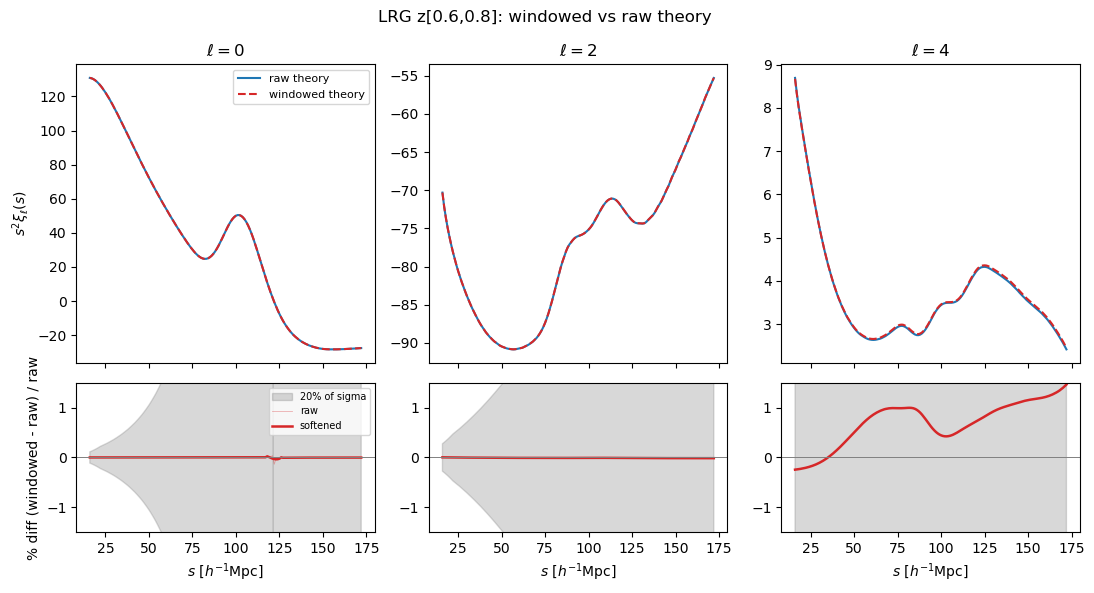

Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|: 4.163336342344337e-16

LRG z[0.8,1.1] -- window impact on theory, s in [16.0, 30.0]:
  ell=0: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=2: max |diff|/sigma = 0.001, at s = 16 Mpc/h


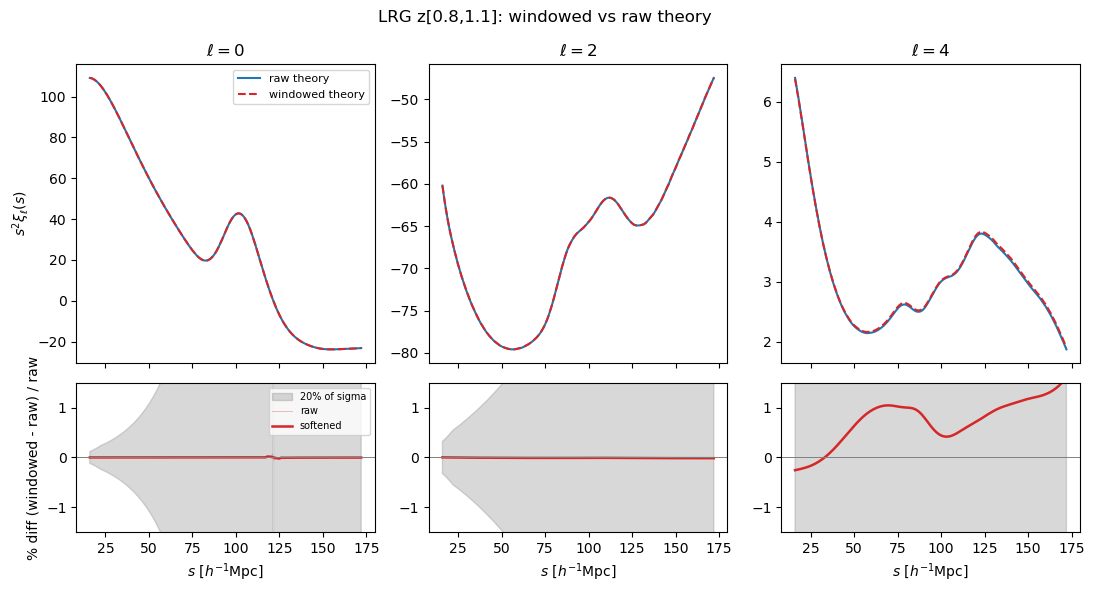

Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|: 2.498001805406602e-16

ELG_LOPnotqso z[1.1,1.6] -- window impact on theory, s in [16.0, 30.0]:
  ell=0: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=2: max |diff|/sigma = 0.001, at s = 30 Mpc/h


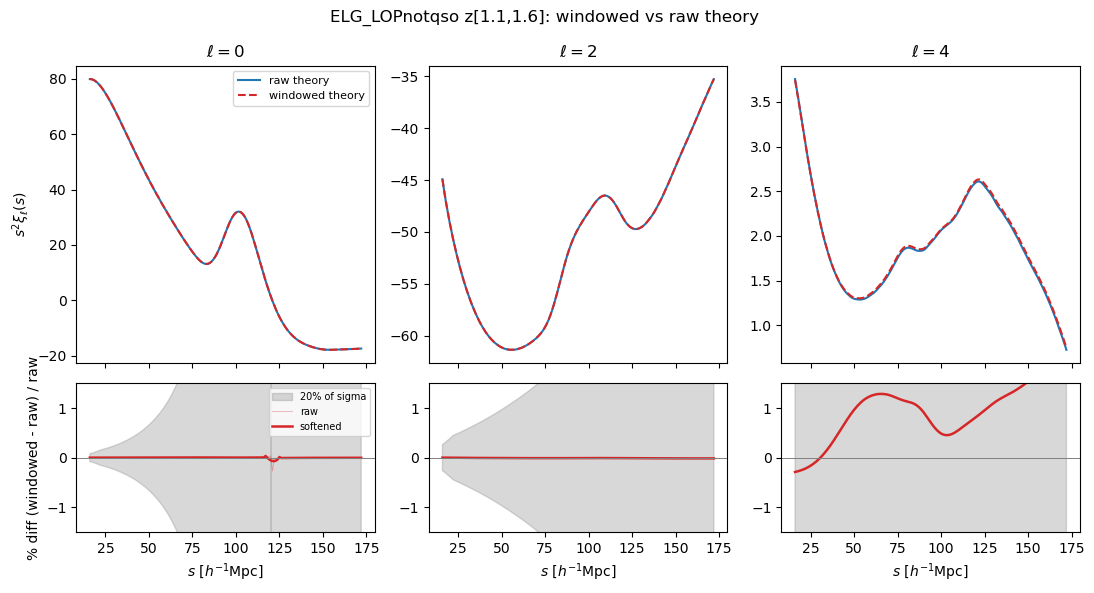

Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|: 1.8735013540549517e-16

QSO z[0.8,2.1] -- window impact on theory, s in [16.0, 30.0]:
  ell=0: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=2: max |diff|/sigma = 0.001, at s = 30 Mpc/h


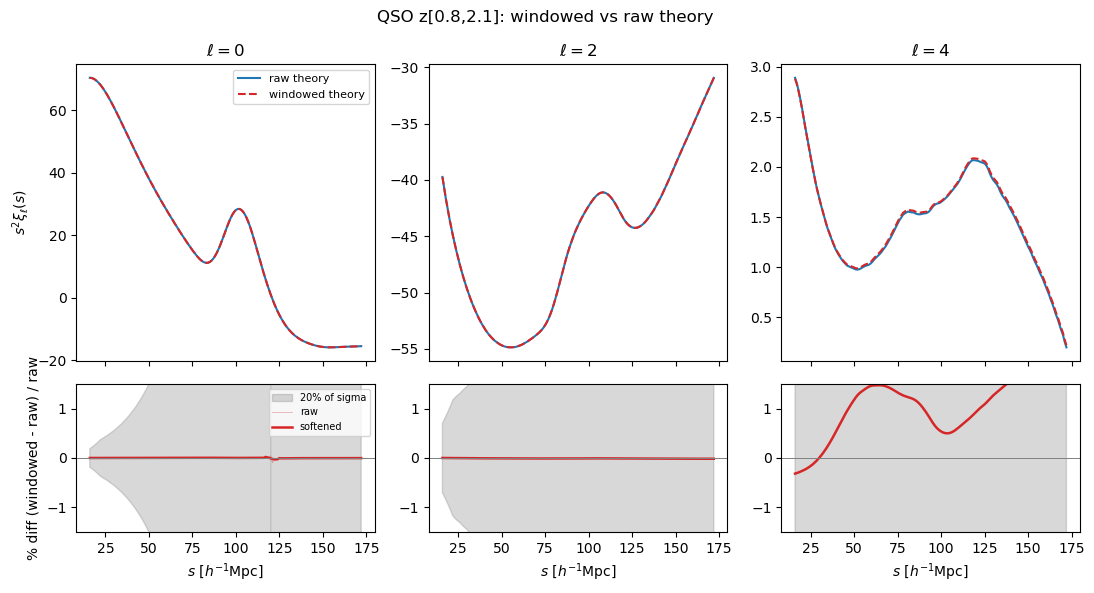

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Run this in your tensorflow environment. It never imports pycorr -- it just
# reads the .npz produced by validate_window_bias_step1_pycorr.py.

# --- pieces reused from your mock-fitting setup script ---
from common import (
    S_MODEL, get_emulators_cached, ap_multipoles, cov_path_for, ELL_ALL, NBINS_COV,
)


def validate(window_npz_path, tracer_str, zmin, zmax, prog, z_eff, theta_fid,
             smin_check=16., smax_check=30.):
    npz = np.load(window_npz_path)
    W_on_smodel, s_model_saved = npz['W'], npz['s_model']
    assert np.allclose(s_model_saved, S_MODEL), (
        'S_MODEL grid in step 1 does not match this environment\'s S_MODEL -- '
        'keep the two constants in sync across both scripts.'
    )

    # 1. theory multipoles on S_MODEL from the emulator, no AP (identity)
    emus = get_emulators_cached(z_eff)
    h, ombh2, omch2, lnAs, b1, b2, ns = theta_fid
    emu_params = [b1, b2, ombh2, omch2, h, lnAs, ns]
    _, xi0 = emus[0](emu_params)
    _, xi2 = emus[1](emu_params)
    _, xi4 = emus[2](emu_params)
    xi_theory_full = np.stack([xi0, xi2, xi4])  # shape (3, len(S_MODEL))

    # sanity check: ap_multipoles with q_perp=q_par=1 should reproduce xi0/xi2
    # directly at S_MODEL points -- confirms the "identity AP" simplification
    # behaves as expected before trusting anything downstream.
    xi_check = ap_multipoles(S_MODEL, (0, 2), xi0, xi2, xi4, q_perp=1., q_par=1.)
    print('Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|:',
          np.max(np.abs(xi_check - xi_theory_full[:2])))

    # 2. apply window: xi_windowed[lo, s] = sum_lt W[lo, lt, s] * xi_theory_full[lt, s]
    xi_windowed = np.einsum('ots,ts->os', W_on_smodel, xi_theory_full)

    # 3. compare windowed vs raw theory for ell=0,2, against covariance errors
    cov = np.loadtxt(cov_path_for(tracer_str, prog, zmin, zmax))
    sigma_ell = np.sqrt(np.diag(cov)).reshape(len(ELL_ALL), NBINS_COV)
    # NOTE: cov's own bins only span s=20-200 -- there is no covariance coverage
    # for s=16-20 at all. np.interp flat-extrapolates the sigma at s=20 down to
    # s=16 below, which is a placeholder, not a real error estimate for that
    # sub-range; treat ratios computed at s<20 as approximate for that reason,
    # separately from the window-construction uncertainty itself.
    cov_s_centers = np.linspace(20 + 2., 200 - 2., NBINS_COV)

    print(f'\n{tracer_str} z[{zmin},{zmax}] -- window impact on theory, '
          f's in [{smin_check}, {smax_check}]:')
    for i, ell in enumerate((0, 2)):
        diff = xi_windowed[i] - xi_theory_full[i]
        mask = (S_MODEL >= smin_check) & (S_MODEL <= smax_check)
        sigma_interp = np.interp(S_MODEL, cov_s_centers, sigma_ell[i])
        ratio = diff[mask] / sigma_interp[mask]
        print(f'  ell={ell}: max |diff|/sigma = {np.max(np.abs(ratio)):.3f}, '
              f'at s = {S_MODEL[mask][np.argmax(np.abs(ratio))]:.0f} Mpc/h')


def plot_fig3_style(window_npz_path, tracer_str, zmin, zmax, prog, z_eff, theta_fid,
                     smax_plot=200., shade_frac=0.2, smooth_window=9, smooth_order=2):
    """Reproduces the structure of Pinon et al. Fig 3: top row s^2 xi_ell(s) for
    raw vs windowed theory, bottom row the softened (Savitzky-Golay smoothed)
    difference s^2 Delta xi_ell(s) with a shaded band at shade_frac (0.2 = 1/5th,
    matching their convention) of the covariance's sigma_ell(s). The residual is
    smoothed rather than shown raw because it's a difference of two smooth
    theory curves dominated by numerical noise from the window's finite pair
    counts, not a signal that should itself be jagged."""
    npz = np.load(window_npz_path)
    W_on_smodel, s_model_saved = npz['W'], npz['s_model']
    assert np.allclose(s_model_saved, S_MODEL)

    emus = get_emulators_cached(z_eff)
    h, ombh2, omch2, lnAs, b1, b2, ns = theta_fid
    emu_params = [b1, b2, ombh2, omch2, h, lnAs, ns]
    _, xi0 = emus[0](emu_params)
    _, xi2 = emus[1](emu_params)
    _, xi4 = emus[2](emu_params)
    xi_theory_full = np.stack([xi0, xi2, xi4])
    xi_windowed = np.einsum('ots,ts->os', W_on_smodel, xi_theory_full)

    cov = np.loadtxt(cov_path_for(tracer_str, prog, zmin, zmax))
    sigma_ell = np.sqrt(np.diag(cov)).reshape(len(ELL_ALL), NBINS_COV)
    cov_s_centers = np.linspace(20 + 2., 200 - 2., NBINS_COV)

    mask = S_MODEL <= smax_plot
    s = S_MODEL[mask]

    fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1]})
    for i, ell in enumerate((0, 2, 4)):
        ax_top, ax_bot = axes[0, i], axes[1, i]

        ax_top.plot(s, s**2 * xi_theory_full[i][mask], color='C0', label='raw theory')
        ax_top.plot(s, s**2 * xi_windowed[i][mask], color='C3', ls='--', label='windowed theory')
        ax_top.set_title(rf'$\ell = {ell}$')
        if i == 0:
            ax_top.set_ylabel(r'$s^2\xi_\ell(s)$')
            ax_top.legend(fontsize=8)

        # Percent difference is unstable near ell's zero-crossings (small-denominator
        # blowup, same issue flagged earlier in this conversation for the raw-vs-cut
        # data comparison) -- softening reduces the visual spike but doesn't remove
        # its cause, so treat spikes near a zero-crossing as an artifact of that,
        # not necessarily a real effect.
        pct_diff = 100. * (xi_windowed[i][mask] - xi_theory_full[i][mask]) / xi_theory_full[i][mask]
        pct_diff_smooth = savgol_filter(pct_diff, window_length=smooth_window, polyorder=smooth_order)
        pct_sigma = 100. * np.interp(s, cov_s_centers, sigma_ell[i]) / xi_theory_full[i][mask]
        ax_bot.fill_between(s, -shade_frac * pct_sigma, shade_frac * pct_sigma,
                             color='gray', alpha=0.3, label=f'{shade_frac:.0%} of sigma' if i == 0 else None)
        ax_bot.plot(s, pct_diff, color='C3', lw=0.6, alpha=0.35, label='raw' if i == 0 else None)
        ax_bot.plot(s, pct_diff_smooth, color='C3', lw=1.8, label='softened' if i == 0 else None)
        ax_bot.axhline(0, color='gray', lw=0.7)
        ax_bot.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$')
        ax_bot.set_ylim(-1.5, 1.5)
        if i == 0:
            ax_bot.set_ylabel('% diff (windowed - raw) / raw')
            ax_bot.legend(fontsize=7)

    fig.suptitle(f'{tracer_str} z[{zmin},{zmax}]: windowed vs raw theory')
    fig.tight_layout()
    plt.show()





TRACER_ZBINS = {
    'LRG':           ('dark', 8,  {(0.4, 0.6): 0.510, (0.6, 0.8): 0.706, (0.8, 1.1): 0.919}),
    'ELG_LOPnotqso': ('dark', 10, {(1.1, 1.6): 1.317}),
    'QSO':           ('dark', 4,  {(0.8, 2.1): 1.491}),
}


if __name__ == '__main__':
    # Same fiducial point used for the earlier LRG check -- reused across all
    # tracers here for a like-for-like comparison rather than tuning per tracer.
    theta_fid_example = [0.6736, 0.02237, 0.1200, np.log(1e10 * 2.083e-9), 1.5, 0.0, 0.9649]

    for tracer, (prog, nran, zbins) in TRACER_ZBINS.items():
        for (zmin, zmax), z_eff in zbins.items():
            npz_path = f'window_{tracer}_z{zmin}-{zmax}.npz'
            validate(npz_path, tracer, zmin, zmax, prog=prog, z_eff=z_eff,
                      theta_fid=theta_fid_example, smin_check=16., smax_check=30.)
            plot_fig3_style(npz_path, tracer, zmin, zmax, prog=prog, z_eff=z_eff,
                             theta_fid=theta_fid_example, smax_plot=200.)

Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|: 9.992007221626409e-16

LRG z[0.4,0.6] -- window impact on theory, s in [16.0, 30.0]:
  ell=0: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=2: max |diff|/sigma = 0.002, at s = 16 Mpc/h
  ell=4: max |diff|/sigma = 0.024, at s = 16 Mpc/h


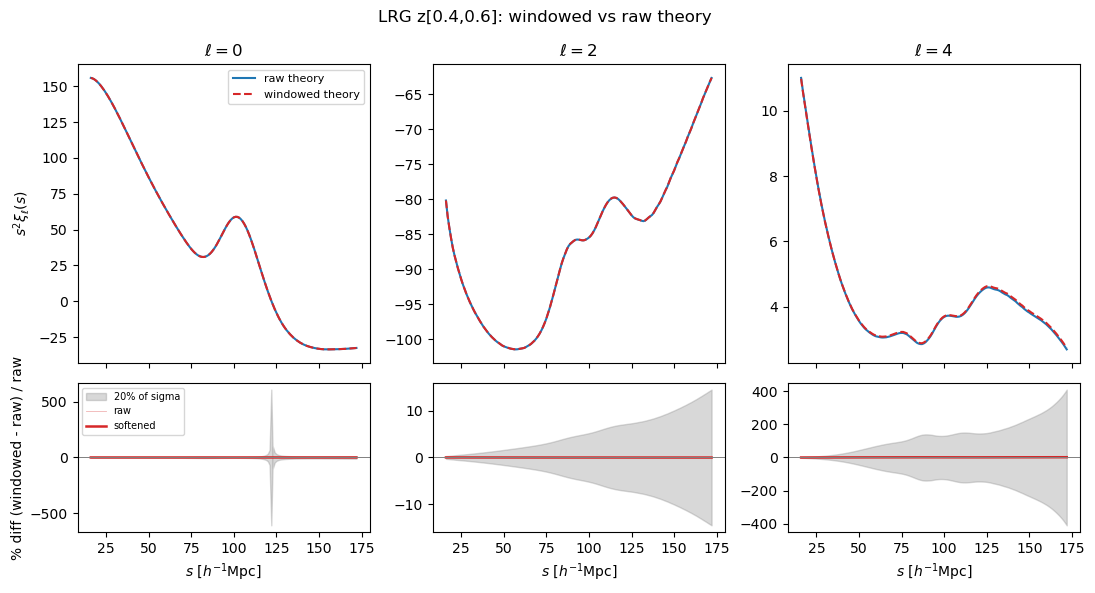

Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|: 6.661338147750939e-16

LRG z[0.6,0.8] -- window impact on theory, s in [16.0, 30.0]:
  ell=0: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=2: max |diff|/sigma = 0.002, at s = 16 Mpc/h
  ell=4: max |diff|/sigma = 0.022, at s = 16 Mpc/h


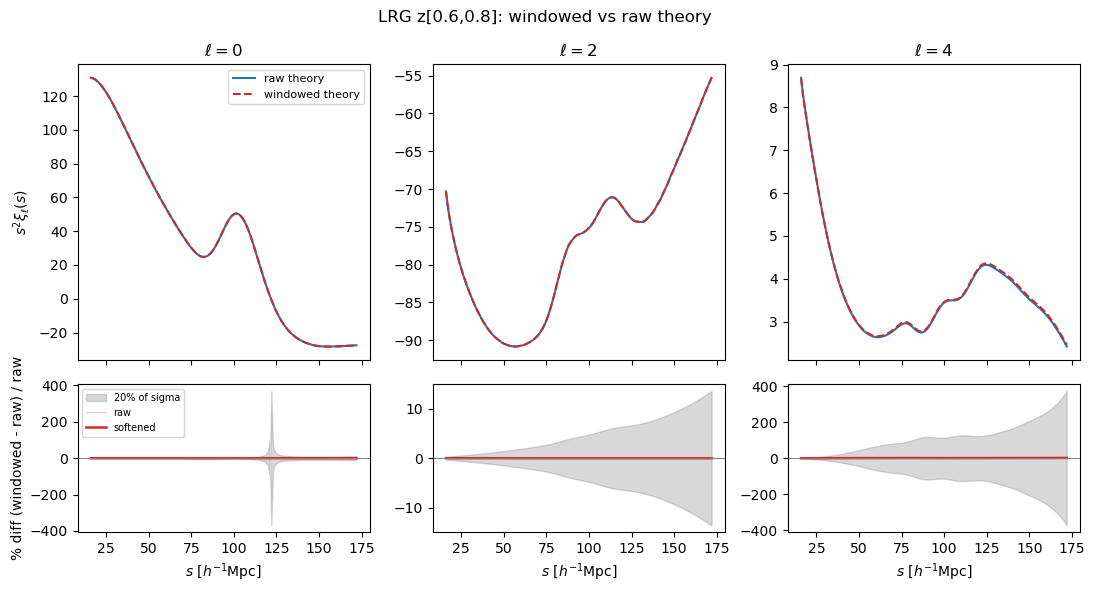

Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|: 4.163336342344337e-16

LRG z[0.8,1.1] -- window impact on theory, s in [16.0, 30.0]:
  ell=0: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=2: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=4: max |diff|/sigma = 0.015, at s = 16 Mpc/h


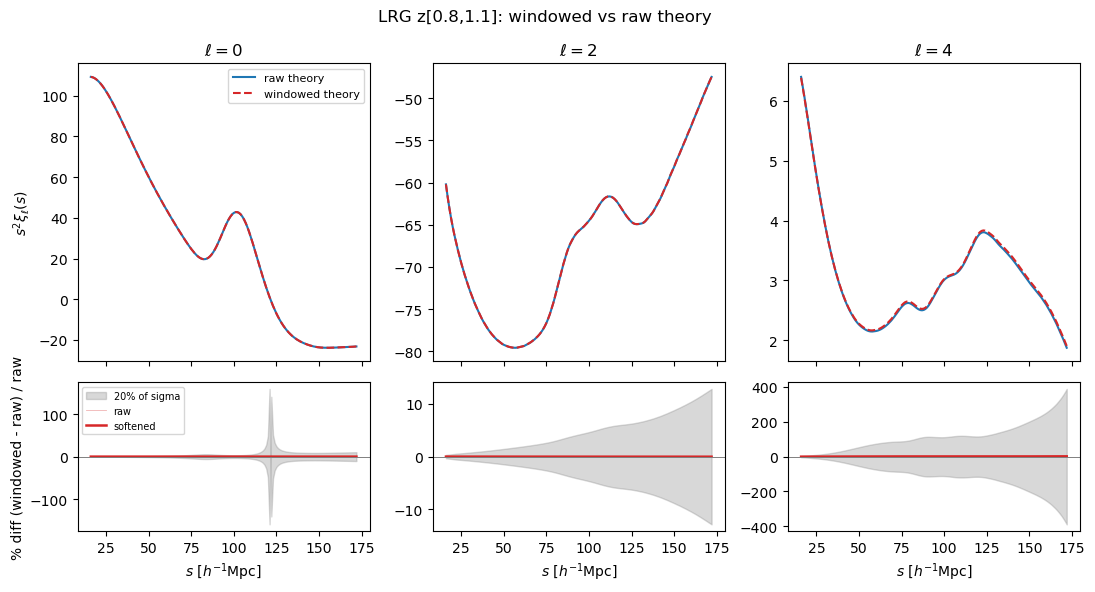

Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|: 2.498001805406602e-16

ELG_LOPnotqso z[1.1,1.6] -- window impact on theory, s in [16.0, 30.0]:
  ell=0: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=2: max |diff|/sigma = 0.001, at s = 30 Mpc/h
  ell=4: max |diff|/sigma = 0.015, at s = 16 Mpc/h


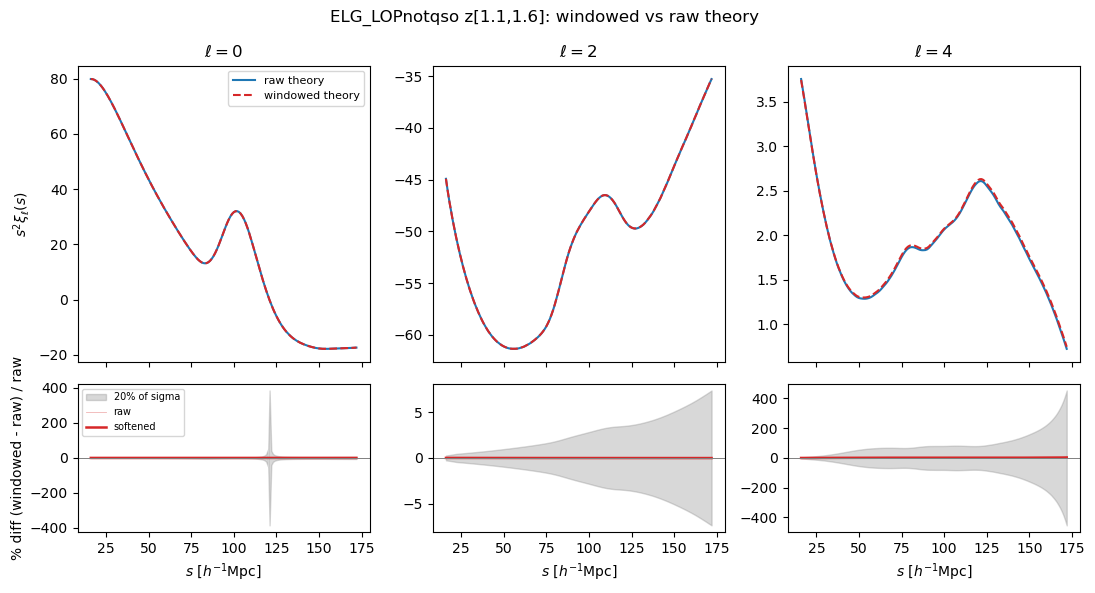

Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|: 1.8735013540549517e-16

QSO z[0.8,2.1] -- window impact on theory, s in [16.0, 30.0]:
  ell=0: max |diff|/sigma = 0.001, at s = 16 Mpc/h
  ell=2: max |diff|/sigma = 0.001, at s = 30 Mpc/h
  ell=4: max |diff|/sigma = 0.005, at s = 16 Mpc/h


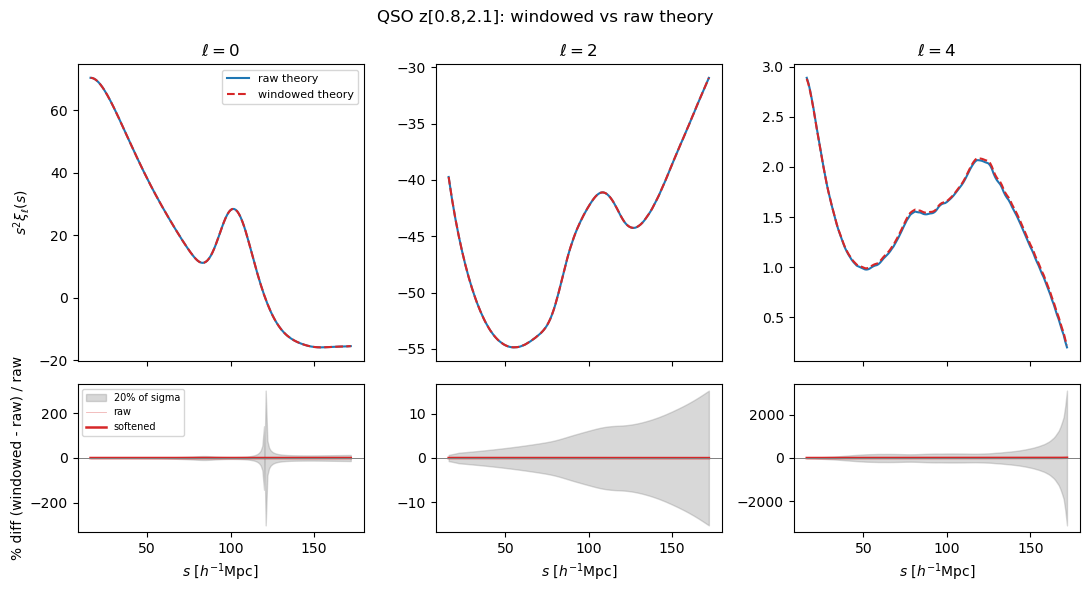

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Run this in your tensorflow environment. It never imports pycorr -- it just
# reads the .npz produced by validate_window_bias_step1_pycorr.py.

# --- pieces reused from your mock-fitting setup script ---
from common import (
    S_MODEL, get_emulators_cached, ap_multipoles, cov_path_for, ELL_ALL, NBINS_COV,
)


def validate(window_npz_path, tracer_str, zmin, zmax, prog, z_eff, theta_fid,
             smin_check=16., smax_check=30.):
    npz = np.load(window_npz_path)
    W_on_smodel, s_model_saved = npz['W'], npz['s_model']
    assert np.allclose(s_model_saved, S_MODEL), (
        'S_MODEL grid in step 1 does not match this environment\'s S_MODEL -- '
        'keep the two constants in sync across both scripts.'
    )

    # 1. theory multipoles on S_MODEL from the emulator, no AP (identity)
    emus = get_emulators_cached(z_eff)
    h, ombh2, omch2, lnAs, b1, b2, ns = theta_fid
    emu_params = [b1, b2, ombh2, omch2, h, lnAs, ns]
    _, xi0 = emus[0](emu_params)
    _, xi2 = emus[1](emu_params)
    _, xi4 = emus[2](emu_params)
    xi_theory_full = np.stack([xi0, xi2, xi4])  # shape (3, len(S_MODEL))

    # sanity check: ap_multipoles with q_perp=q_par=1 should reproduce xi0/xi2
    # directly at S_MODEL points -- confirms the "identity AP" simplification
    # behaves as expected before trusting anything downstream.
    xi_check = ap_multipoles(S_MODEL, (0, 2), xi0, xi2, xi4, q_perp=1., q_par=1.)
    print('Max |ap_multipoles(identity AP) - raw emulator xi0,xi2|:',
          np.max(np.abs(xi_check - xi_theory_full[:2])))

    # 2. apply window: xi_windowed[lo, s] = sum_lt W[lo, lt, s] * xi_theory_full[lt, s]
    xi_windowed = np.einsum('ots,ts->os', W_on_smodel, xi_theory_full)

    # 3. compare windowed vs raw theory for ell=0,2, against covariance errors
    cov = np.loadtxt(cov_path_for(tracer_str, prog, zmin, zmax))
    sigma_ell = np.sqrt(np.diag(cov)).reshape(len(ELL_ALL), NBINS_COV)
    # NOTE: cov's own bins only span s=20-200 -- there is no covariance coverage
    # for s=16-20 at all. np.interp flat-extrapolates the sigma at s=20 down to
    # s=16 below, which is a placeholder, not a real error estimate for that
    # sub-range; treat ratios computed at s<20 as approximate for that reason,
    # separately from the window-construction uncertainty itself.
    cov_s_centers = np.linspace(20 + 2., 200 - 2., NBINS_COV)

    print(f'\n{tracer_str} z[{zmin},{zmax}] -- window impact on theory, '
          f's in [{smin_check}, {smax_check}]:')
    for i, ell in enumerate((0, 2, 4)):
        diff = xi_windowed[i] - xi_theory_full[i]
        mask = (S_MODEL >= smin_check) & (S_MODEL <= smax_check)
        sigma_interp = np.interp(S_MODEL, cov_s_centers, sigma_ell[i])
        ratio = diff[mask] / sigma_interp[mask]
        print(f'  ell={ell}: max |diff|/sigma = {np.max(np.abs(ratio)):.3f}, '
              f'at s = {S_MODEL[mask][np.argmax(np.abs(ratio))]:.0f} Mpc/h')


def plot_fig3_style(window_npz_path, tracer_str, zmin, zmax, prog, z_eff, theta_fid,
                     smax_plot=200., shade_frac=0.2, smooth_window=9, smooth_order=2):
    """Reproduces the structure of Pinon et al. Fig 3: top row s^2 xi_ell(s) for
    raw vs windowed theory, bottom row the softened (Savitzky-Golay smoothed)
    difference s^2 Delta xi_ell(s) with a shaded band at shade_frac (0.2 = 1/5th,
    matching their convention) of the covariance's sigma_ell(s). The residual is
    smoothed rather than shown raw because it's a difference of two smooth
    theory curves dominated by numerical noise from the window's finite pair
    counts, not a signal that should itself be jagged."""
    npz = np.load(window_npz_path)
    W_on_smodel, s_model_saved = npz['W'], npz['s_model']
    assert np.allclose(s_model_saved, S_MODEL)

    emus = get_emulators_cached(z_eff)
    h, ombh2, omch2, lnAs, b1, b2, ns = theta_fid
    emu_params = [b1, b2, ombh2, omch2, h, lnAs, ns]
    _, xi0 = emus[0](emu_params)
    _, xi2 = emus[1](emu_params)
    _, xi4 = emus[2](emu_params)
    xi_theory_full = np.stack([xi0, xi2, xi4])
    xi_windowed = np.einsum('ots,ts->os', W_on_smodel, xi_theory_full)

    cov = np.loadtxt(cov_path_for(tracer_str, prog, zmin, zmax))
    sigma_ell = np.sqrt(np.diag(cov)).reshape(len(ELL_ALL), NBINS_COV)
    cov_s_centers = np.linspace(20 + 2., 200 - 2., NBINS_COV)

    mask = S_MODEL <= smax_plot
    s = S_MODEL[mask]

    fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1]})
    for i, ell in enumerate((0, 2, 4)):
        ax_top, ax_bot = axes[0, i], axes[1, i]

        ax_top.plot(s, s**2 * xi_theory_full[i][mask], color='C0', label='raw theory')
        ax_top.plot(s, s**2 * xi_windowed[i][mask], color='C3', ls='--', label='windowed theory')
        ax_top.set_title(rf'$\ell = {ell}$')
        if i == 0:
            ax_top.set_ylabel(r'$s^2\xi_\ell(s)$')
            ax_top.legend(fontsize=8)

        # Percent difference is unstable near ell's zero-crossings (small-denominator
        # blowup, same issue flagged earlier in this conversation for the raw-vs-cut
        # data comparison) -- softening reduces the visual spike but doesn't remove
        # its cause, so treat spikes near a zero-crossing as an artifact of that,
        # not necessarily a real effect.
        pct_diff = 100. * (xi_windowed[i][mask] - xi_theory_full[i][mask]) / xi_theory_full[i][mask]
        pct_diff_smooth = savgol_filter(pct_diff, window_length=smooth_window, polyorder=smooth_order)
        pct_sigma = 100. * np.interp(s, cov_s_centers, sigma_ell[i]) / xi_theory_full[i][mask]
        ax_bot.fill_between(s, -shade_frac * pct_sigma, shade_frac * pct_sigma,
                             color='gray', alpha=0.3, label=f'{shade_frac:.0%} of sigma' if i == 0 else None)
        ax_bot.plot(s, pct_diff, color='C3', lw=0.6, alpha=0.35, label='raw' if i == 0 else None)
        ax_bot.plot(s, pct_diff_smooth, color='C3', lw=1.8, label='softened' if i == 0 else None)
        ax_bot.axhline(0, color='gray', lw=0.7)
        ax_bot.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$')
        if i == 0:
            ax_bot.set_ylabel('% diff (windowed - raw) / raw')
            ax_bot.legend(fontsize=7)

    fig.suptitle(f'{tracer_str} z[{zmin},{zmax}]: windowed vs raw theory')
    fig.tight_layout()
    plt.show()





TRACER_ZBINS = {
    'LRG':           ('dark', 8,  {(0.4, 0.6): 0.510, (0.6, 0.8): 0.706, (0.8, 1.1): 0.919}),
    'ELG_LOPnotqso': ('dark', 10, {(1.1, 1.6): 1.317}),
    'QSO':           ('dark', 4,  {(0.8, 2.1): 1.491}),
}


if __name__ == '__main__':
    # Same fiducial point used for the earlier LRG check -- reused across all
    # tracers here for a like-for-like comparison rather than tuning per tracer.
    theta_fid_example = [0.6736, 0.02237, 0.1200, np.log(1e10 * 2.083e-9), 1.5, 0.0, 0.9649]

    for tracer, (prog, nran, zbins) in TRACER_ZBINS.items():
        for (zmin, zmax), z_eff in zbins.items():
            npz_path = f'window_{tracer}_z{zmin}-{zmax}.npz'
            validate(npz_path, tracer, zmin, zmax, prog=prog, z_eff=z_eff,
                      theta_fid=theta_fid_example, smin_check=16., smax_check=30.)
            plot_fig3_style(npz_path, tracer, zmin, zmax, prog=prog, z_eff=z_eff,
                             theta_fid=theta_fid_example, smax_plot=200.)